<a href="https://colab.research.google.com/github/korgaonkarparth2522-max/CSL701-CSE26_Machine-Learning-Lab/blob/main/Experiment/ML_Experiment_5_Bagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Parth Shantaram Korgaonkar

Roll No: Cs26

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [1]:
# Task 1: Environment Setup and Dataset Acquisition

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Column names
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# Download dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

df = pd.read_csv(url, names=columns)

# Display first five records
print("First 5 records:")
display(df.head())

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

First 5 records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset Shape:
(768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


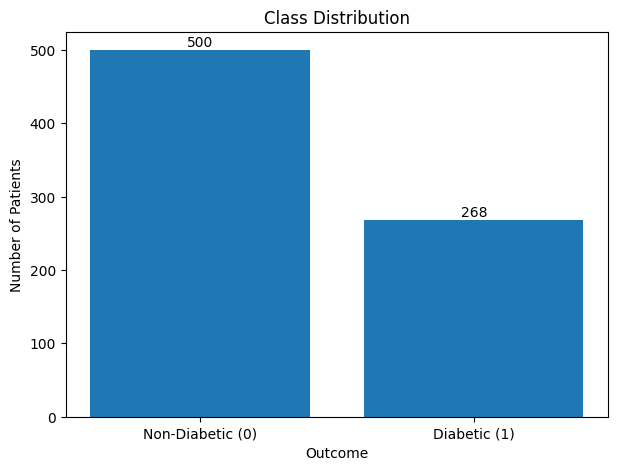

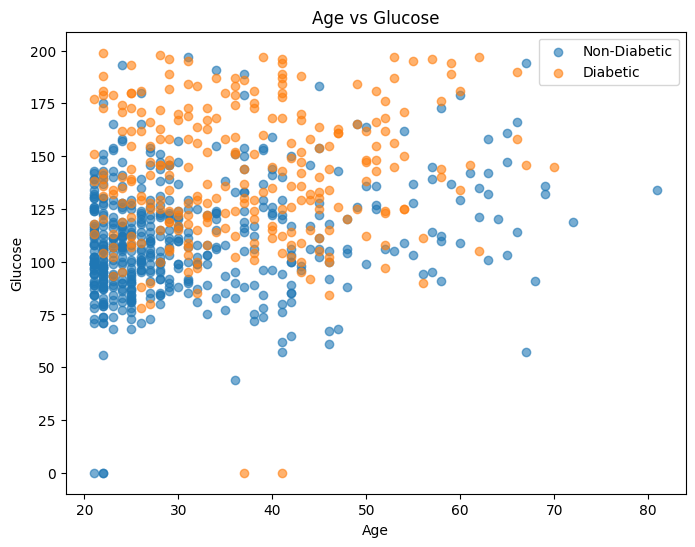

In [2]:
# Task 2: Exploratory Data Analysis

# Count of each class
class_counts = df["Outcome"].value_counts().sort_index()

# Percentage of each class
class_percentages = df["Outcome"].value_counts(
    normalize=True
).sort_index() * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages)


# -----------------------------------
# Bar Chart - Class Balance
# -----------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Diabetic (0)", "Diabetic (1)"],
    class_counts.values
)

plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.title("Class Distribution")

for i, value in enumerate(class_counts.values):
    plt.text(i, value + 5, str(value), ha="center")

plt.show()


# -----------------------------------
# Scatter Plot - Age vs Glucose
# -----------------------------------

plt.figure(figsize=(8, 6))

for outcome in [0, 1]:
    subset = df[df["Outcome"] == outcome]

    plt.scatter(
        subset["Age"],
        subset["Glucose"],
        label="Diabetic" if outcome == 1 else "Non-Diabetic",
        alpha=0.6
    )

plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Age vs Glucose")
plt.legend()
plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [3]:
# Task 3: Preprocessing and Handling Missing Values

# Features where zero is physically impossible
invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Count invalid zero values
print("Invalid zero values before replacement:\n")

for column in invalid_zero_columns:
    print(
        column,
        ":",
        (df[column] == 0).sum()
    )


# Replace zero with NaN
df[invalid_zero_columns] = df[
    invalid_zero_columns
].replace(0, np.nan)


# Check missing values
print("\nMissing values after replacing zeros:")
print(df.isnull().sum())


# Fill missing values using median
for column in invalid_zero_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )


# Final check
print("\nMissing values after median imputation:")
print(df.isnull().sum())

print("\nDataset after preprocessing:")
display(df.head())

Invalid zero values before replacement:

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dataset after preprocessing:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [4]:
# Task 4: Stratified Train-Test Split

# Feature matrix
X = df.iloc[:, :8]

# Target variable
y = df.iloc[:, 8]

# Stratified 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Class Distribution:")
print(y_test.value_counts(normalize=True))

Training Data Shape:
(614, 8)

Testing Data Shape:
(154, 8)

Training Class Distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing Class Distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [5]:
# Task 5: Custom Bootstrap Sampling Function

def get_bootstrap_sample(X, y):

    # Number of training samples
    n_samples = len(X)

    # Generate random indices with replacement
    indices = np.random.choice(
        n_samples,
        size=n_samples,
        replace=True
    )

    # Create bootstrap samples
    X_bootstrap = X.iloc[indices].reset_index(drop=True)
    y_bootstrap = y.iloc[indices].reset_index(drop=True)

    return X_bootstrap, y_bootstrap, indices


# Generate one bootstrap sample
X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)

print("Original training samples:", len(X_train))
print("Bootstrap samples:", len(X_bootstrap))


# Find duplicate indices
unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

duplicate_indices = unique_indices[counts > 1]

print("\nNumber of duplicated indices:")
print(len(duplicate_indices))

print("\nDuplicated indices:")
print(duplicate_indices[:20])


# Find OOB indices
all_indices = set(range(len(X_train)))

selected_indices = set(bootstrap_indices)

oob_indices = sorted(
    all_indices - selected_indices
)

print("\nNumber of OOB samples:")
print(len(oob_indices))

print("\nFirst few OOB indices:")
print(oob_indices[:20])

Original training samples: 614
Bootstrap samples: 614

Number of duplicated indices:
155

Duplicated indices:
[ 6 12 17 22 23 25 28 30 40 43 44 50 51 61 62 66 69 76 80 83]

Number of OOB samples:
222

First few OOB indices:
[0, 1, 3, 4, 8, 11, 14, 15, 16, 20, 21, 29, 31, 32, 36, 37, 42, 45, 47, 48]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [6]:
# Task 6: Growing the Ensemble of Base Classifiers

# Number of bootstrap iterations
B = 50

# Empty list for models
ensemble = []

# Train 50 decision trees
for i in range(B):

    # Generate bootstrap sample
    X_bootstrap, y_bootstrap, _ = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create fully grown decision tree
    tree = DecisionTreeClassifier(
        max_depth=None,
        random_state=i
    )

    # Train tree
    tree.fit(
        X_bootstrap,
        y_bootstrap
    )

    # Add tree to ensemble
    ensemble.append(tree)


print("Number of trees in ensemble:")
print(len(ensemble))

Number of trees in ensemble:
50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [7]:
# Task 7: Custom Majority Voting

def custom_bagging_predict(ensemble, X_test):

    # Store predictions from every tree
    all_predictions = []

    for model in ensemble:
        predictions = model.predict(X_test)
        all_predictions.append(predictions)

    # Convert to NumPy array
    all_predictions = np.array(all_predictions)

    # Majority voting
    final_predictions = []

    for i in range(all_predictions.shape[1]):

        # Get predictions for one sample
        sample_predictions = all_predictions[:, i]

        # Count votes
        counts = np.bincount(
            sample_predictions.astype(int)
        )

        # Select class with maximum votes
        final_class = np.argmax(counts)

        final_predictions.append(final_class)

    return np.array(final_predictions)


# Generate Bagging predictions
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

print("First 20 Bagging Predictions:")
print(y_pred_bagging[:20])

print("\nActual Values:")
print(y_test.values[:20])

First 20 Bagging Predictions:
[1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0]

Actual Values:
[0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.


Single Decision Tree
Accuracy : 0.6818181818181818
Precision: 0.5531914893617021
Recall   : 0.48148148148148145
F1-Score : 0.5148514851485149

Confusion Matrix:
[[79 21]
 [28 26]]

Custom Bagging
Accuracy : 0.7272727272727273
Precision: 0.6304347826086957
Recall   : 0.5370370370370371
F1-Score : 0.58

Confusion Matrix:
[[83 17]
 [25 29]]


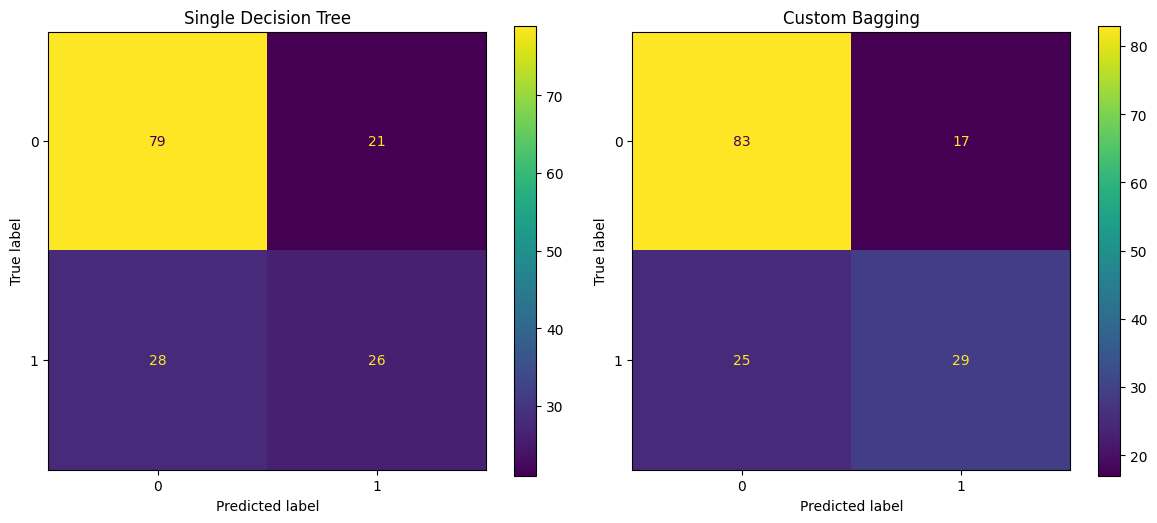

In [8]:
# Task 8: Single Decision Tree vs Custom Bagging

# -----------------------------------
# Single Decision Tree
# -----------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(
    X_train,
    y_train
)

y_pred_tree = single_tree.predict(X_test)


# -----------------------------------
# Bagging Prediction
# -----------------------------------

y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


# -----------------------------------
# Performance Function
# -----------------------------------

def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print("\n==============================")
    print(name)
    print("==============================")

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


# Evaluate both
evaluate_model(
    "Single Decision Tree",
    y_test,
    y_pred_tree
)

evaluate_model(
    "Custom Bagging",
    y_test,
    y_pred_bagging
)


# -----------------------------------
# Confusion Matrix Graphs
# -----------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    ax=axes[0]
)

axes[0].set_title("Single Decision Tree")


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_bagging,
    ax=axes[1]
)

axes[1].set_title("Custom Bagging")

plt.tight_layout()
plt.show()

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

Single Decision Tree AUC:
0.6357407407407407

Custom Bagging AUC:
0.8018518518518518


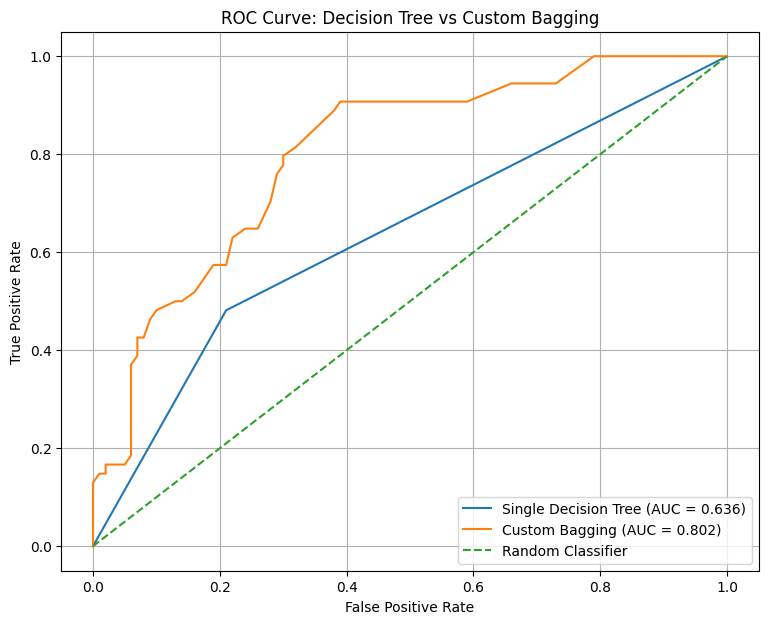

In [9]:
# Task 9: ROC-AUC Analysis

# -----------------------------------
# Single Decision Tree Probabilities
# -----------------------------------

y_prob_tree = single_tree.predict_proba(X_test)[:, 1]


# -----------------------------------
# Bagging Probabilities
# -----------------------------------

all_probabilities = []

for model in ensemble:

    probabilities = model.predict_proba(X_test)[:, 1]

    all_probabilities.append(probabilities)


# Average probabilities from all trees
y_prob_bagging = np.mean(
    all_probabilities,
    axis=0
)


# -----------------------------------
# Calculate ROC-AUC
# -----------------------------------

auc_tree = roc_auc_score(
    y_test,
    y_prob_tree
)

auc_bagging = roc_auc_score(
    y_test,
    y_prob_bagging
)

print("Single Decision Tree AUC:")
print(auc_tree)

print("\nCustom Bagging AUC:")
print(auc_bagging)


# -----------------------------------
# ROC Curves
# -----------------------------------

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_prob_tree
)

fpr_bagging, tpr_bagging, _ = roc_curve(
    y_test,
    y_prob_bagging
)


# Plot ROC curves
plt.figure(figsize=(9, 7))

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Single Decision Tree (AUC = {auc_tree:.3f})"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Custom Bagging (AUC = {auc_bagging:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Decision Tree vs Custom Bagging")
plt.legend()
plt.grid()
plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

CUSTOM BAGGING vs SCIKIT-LEARN BAGGING

Custom Bagging Accuracy:
0.7272727272727273

Scikit-Learn Bagging Accuracy:
0.7337662337662337

Custom Bagging Confusion Matrix:
[[83 17]
 [25 29]]

Scikit-Learn Bagging Confusion Matrix:
[[85 15]
 [26 28]]


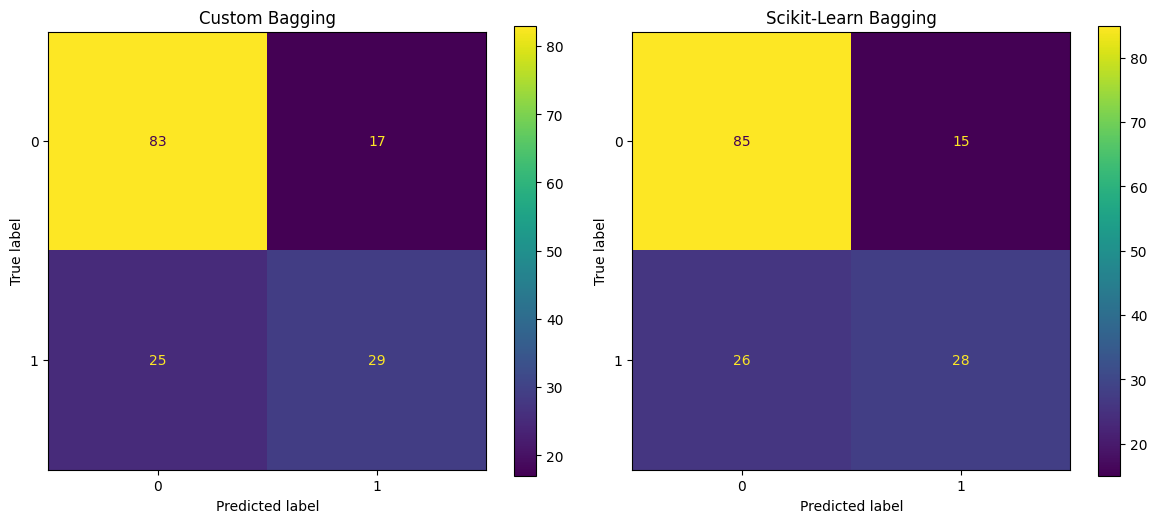

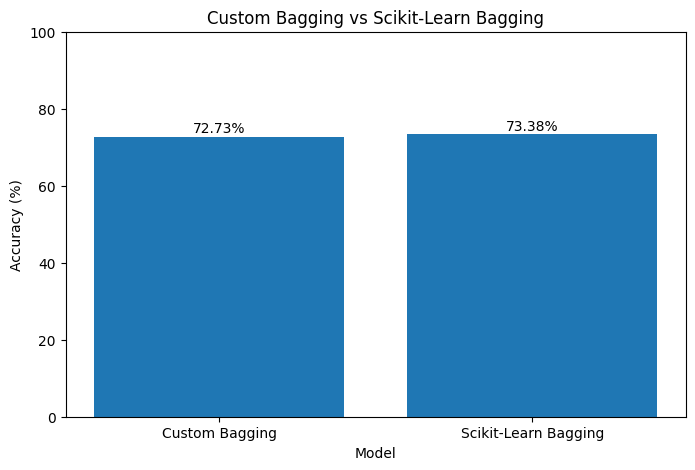

In [10]:
# Task 10: Validation against Scikit-Learn BaggingClassifier

from sklearn.ensemble import BaggingClassifier

# -----------------------------------
# Create Scikit-Learn Bagging Model
# -----------------------------------

base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

sklearn_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    random_state=42
)


# -----------------------------------
# Train Model
# -----------------------------------

sklearn_bagging.fit(
    X_train,
    y_train
)


# -----------------------------------
# Make Predictions
# -----------------------------------

y_pred_sklearn = sklearn_bagging.predict(
    X_test
)


# -----------------------------------
# Calculate Accuracy
# -----------------------------------

custom_accuracy = accuracy_score(
    y_test,
    y_pred_bagging
)

sklearn_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn
)


print("========================================")
print("CUSTOM BAGGING vs SCIKIT-LEARN BAGGING")
print("========================================")

print("\nCustom Bagging Accuracy:")
print(custom_accuracy)

print("\nScikit-Learn Bagging Accuracy:")
print(sklearn_accuracy)


# -----------------------------------
# Confusion Matrices
# -----------------------------------

cm_custom = confusion_matrix(
    y_test,
    y_pred_bagging
)

cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)

print("\nCustom Bagging Confusion Matrix:")
print(cm_custom)

print("\nScikit-Learn Bagging Confusion Matrix:")
print(cm_sklearn)


# -----------------------------------
# Confusion Matrix Graphs
# -----------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_bagging,
    ax=axes[0]
)

axes[0].set_title("Custom Bagging")


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_sklearn,
    ax=axes[1]
)

axes[1].set_title("Scikit-Learn Bagging")


plt.tight_layout()
plt.show()


# -----------------------------------
# Accuracy Comparison Graph
# -----------------------------------

models = [
    "Custom Bagging",
    "Scikit-Learn Bagging"
]

accuracies = [
    custom_accuracy * 100,
    sklearn_accuracy * 100
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    models,
    accuracies
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Custom Bagging vs Scikit-Learn Bagging")

plt.ylim(0, 100)

for bar, value in zip(bars, accuracies):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

Conclusion and Interpretation

1. Variance and Stability:
The Bagging ensemble generally provides more stable performance than a single Decision Tree. A single decision tree can be sensitive to changes in the training data, while Bagging trains multiple decision trees on different bootstrap samples and combines their predictions. This reduces the effect of individual tree errors and helps provide more consistent results.

2. Wisdom of Crowds:
Bootstrapping creates different training datasets by randomly selecting samples with replacement. As a result, each decision tree learns slightly different patterns from the data. The final prediction is obtained through majority voting among all the trees. Combining the decisions of many models helps reduce the influence of an individual incorrect prediction, producing a more reliable ensemble prediction.

3. Clinical Interpretation:
A False Negative occurs when a diabetic patient is incorrectly predicted as non-diabetic. This can be costly because the patient may not receive appropriate medical attention or further testing. Recall measures how effectively the model identifies actual diabetic cases. Therefore, comparing the Recall of the Bagging ensemble with the single Decision Tree is important. A higher recall means fewer diabetic patients are missed by the model.